# <center>MDSA D212 Data Mining II</center> 

## <center>Task 1  Clustering Techniques</center>

## <center>Justin Jordan</center>

## <center>5/15/2026</center>

## <center>WGU</center>



### Scenario 1
One of the most critical factors in customer relationship management that directly affects a company’s long-term profitability is understanding the customers. When a company understands its customers’ characteristics, it is better able to target products and marketing campaigns for customers, resulting in better profits for the company in the long term.



You are an analyst for a telecommunications company that wants to better understand the characteristics of its customers. You have been asked to use clustering techniques to analyze customer data to identify groups of customers with similar characteristics, ultimately enabling better business and strategic decision-making.

## Part I: Research Question

### A.  Describe the purpose of this data mining by doing the following:

1.  Propose one question relevant to a real-world organizational situation that you will answer using one of the following clustering techniques:

    •  k-means, using only continuous variables

    •  hierarchical

    - Can customers be grouped into categories based on the survey responses available within the churn dataset using K-Means clustering to create better marketing?  I believe this is an important question to an organization as it costs 10 times more to acquire a new customer than to retain an existing one(Churn Data Consideration and Dictionary 2024).    

2.  Define one goal of the data analysis. Ensure that your goal is reasonable within the scope of the scenario and is represented in the available data.
    - The goal of this analysis is to use K-Means clustering to define groups based off of the chosen variables and identify any patterns or correlation to help marketing with customer retention.      

## Part II: Method Justification

### B.   Explain the reasons for your chosen clustering technique from part A1 by doing the following::

1.  Explain how the clustering technique you chose analyzes the selected data set. Include expected outcomes.
    - K-means clustering is an unsupervised learning algorithm used for data clustering, which groups unlabeled data points into groups or clusters (Kavlakoglu & Winland, 2025).  K-Mean clustering assigns datapoints to the nearest randomly centroid.  It then reissues the cetroids based on the mean of the datapoints within the group.  This process repeats until there no significant change.  The elbow method will be used to determine the K value.  Once we have our K value, we will generate clusters which will return metrics to determine the significance of each cluster.  Expected outcome is all data points assigned to a cluster.      

2.  Summarize one assumption of the clustering technique.
    -   One assumption of K-Means clustering is clusters are assumed to be spherical, which means their radius is approximately eual in all directions.  The cluster center is assigned to the mean that the algorithm determines from the average of the data points within a cluster. Because of this presumption, K-means is susceptible to non-spherical or elongated clusters(GeeksforGeeks, 2025).  Another assumption is that the scale of the variables can influence clustering results.  To avoid needing to scale the variables used, we will be using the survey results(Item1 thru 8) as they are all already on the same scale.     

3.  List the packages or libraries you have chosen for Python or R, and justify how each item on the list supports the analysis.
    -  In this analysis, we will be using Python within a Jupyter notebook. This gives us the ease and flexibility to have code and markdown cells in one easy to follow document. Python combined with Jupyter make it easy for not only implementing and reading code, but also creating the visual representations of the code all in one place making it easier to understand the data that is being worked with.  Packages that will be used within Python are as follows:
        - Pandas and Numpy for preperation and analysis
        - Seaborn and Matplotlib for data visualization
        - Scikit-learn for machine learning and predictive modeling
        
        

## Part III: Data Preparation

### C.  Perform data preparation for the chosen data set by doing the following:

1.  Describe one data preprocessing goal relevant to the clustering technique from part A1.
- The goal is to have a clean data set that can be used for K-means clustering.  Another goal will be to reduce the size of the dataset.  The original dataset has more columns that what is needed for this analysis.  The will be a more efficient approach and less cluttered.  


2.  Identify the initial data set variables you will use to perform the analysis for the clustering question from part A1, and label each as continuous or categorical.

    - Item1  continuous
    - Item2  continuous
    - Item3  continuous
    - Item4  continuous
    - Item5  continuous
    - Item6  continuous
    - Item7  continuous
    - Item8  continuous

    These will also be renamed as part of the cleaning process to reflect what the survey items actually are. Below shows the new names as well as the original.  It is also important to note we will not need to scale these variables as they are all on the same scale already.  All variables listed below will still be continuous. 

        - "Item1": "Timely_response" (continuous)
        - "Item2": "Timely_fixes" (continuous)
        - "Item3": "Timely_replacements" (continuous)
        - "Item4": "Reliability" (continuous)
        - "Item5": "Options" (continuous)
        - "Item6": "Respectful_response" (continuous)
        - "Item7": "Courteous_exchange" (continuous)
        - "Item8": "Active_listening" (continuous)

3. Explain each of the steps used to prepare the data for the analysis. Identify the code segment for each step.
    - needed packages will be imported into Python
    - pd.read_csv will be used to load data frame
    - .info() will be used to profile data frame
    - inspect data frame for duplicate values
    - .isnull().sum will be used to identify possible missing values
    - if missing values exist, they will be treated with imputation
    - rename columns
    - create dataframe for variables
    - export cleaned dataframe
      
    
4. Provide a copy of the cleaned data set.

- Code for C3 & C4 is below.

In [67]:
# code for c3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sklearn
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# code for data frame
churn = pd.read_csv("C:/users/jjord/Documents/WGU/D212/d212_pa1/churn_clean.csv")

# Profile of Data Frame
churn.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [68]:
# Missing values using isnull
churn.isnull().sum()

CaseOrder                  0
Customer_id                0
Interaction                0
UID                        0
City                       0
State                      0
County                     0
Zip                        0
Lat                        0
Lng                        0
Population                 0
Area                       0
TimeZone                   0
Job                        0
Children                   0
Age                        0
Income                     0
Marital                    0
Gender                     0
Churn                      0
Outage_sec_perweek         0
Email                      0
Contacts                   0
Yearly_equip_failure       0
Techie                     0
Contract                   0
Port_modem                 0
Tablet                     0
InternetService         2129
Phone                      0
Multiple                   0
OnlineSecurity             0
OnlineBackup               0
DeviceProtection           0
TechSupport   

In [69]:
# look at unique values for InternetService
churn.InternetService.unique()

array(['Fiber Optic', 'DSL', nan], dtype=object)

In [70]:
# Impute nulls for InternetService
churn["InternetService"].fillna("No Internet Service", inplace=True)

In [71]:
# verify InternetService no longer has nulls
churn["InternetService"].isnull().sum()

0

Columns Zip, Lat, Lng currently are floats or ints. There are not quantitative so will change datatype to object. These values are not meant for any type of calculation. Since the rest of the data types for categorical are set to object, these will aslo.

In [72]:
obj_columns = ["Zip", "Lat", "Lng"]
churn[obj_columns] = churn[obj_columns].astype(object)

In [73]:
# rename item columns
churn.rename(
    columns={
        "Item1": "Timely_response",
        "Item2": "Timely_fixes",
        "Item3": "Timely_replacements",
        "Item4": "Reliability",
        "Item5": "Options",
        "Item6": "Respectful_response",
        "Item7": "Courteous_exchange",
        "Item8": "Active_listening",
    },
    inplace=True,
)

In [74]:
#profile df after clean
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  object 
 8   Lat                   10000 non-null  object 
 9   Lng                   10000 non-null  object 
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [75]:
# code for outliers.
churn.describe()

,CaseOrder,Population,Children,Age,Income,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Tenure,MonthlyCharge,Bandwidth_GB_Year,Timely_response,Timely_fixes,Timely_replacements,Reliability,Options,Respectful_response,Courteous_exchange,Active_listening
count,10000.00000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,9756.562400,2.0877,53.078400,39806.926771,10.001848,12.016000,0.994200,0.398000,34.526188,172.624816,3392.341550,3.490800,3.505100,3.487000,3.497500,3.492900,3.497300,3.509500,3.495600
std,2886.89568,14432.698671,2.1472,20.698882,28199.916702,2.976019,3.025898,0.988466,0.635953,26.443063,42.943094,2185.294852,1.037797,1.034641,1.027977,1.025816,1.024819,1.033586,1.028502,1.028633
min,1.00000,0.000000,0.0000,18.000000,348.670000,0.099747,1.000000,0.000000,0.000000,1.000259,79.978860,155.506715,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,738.000000,0.0000,35.000000,19224.717500,8.018214,10.000000,0.000000,0.000000,7.917694,139.979239,1236.470827,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,5000.50000,2910.500000,1.0000,53.000000,33170.605000,10.018560,12.000000,1.000000,0.000000,35.430507,167.484700,3279.536903,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000
75%,7500.25000,13168.000000,3.0000,71.000000,53246.170000,11.969485,14.000000,2.000000,1.000000,61.479795,200.734725,5586.141370,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,10000.00000,111850.000000,10.0000,89.000000,258900.700000,21.207230,23.000000,7.000000,6.000000,71.999280,290.160419,7158.981530,7.000000,7.000000,8.000000,7.000000,7.000000,8.000000,7.000000,8.000000


In [76]:
# dataframe for variables

prep_churn = churn[["Timely_response","Timely_fixes","Timely_replacements","Reliability","Options","Respectful_response","Courteous_exchange","Active_listening"]]



In [77]:
# profile df
prep_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Timely_response      10000 non-null  int64
 1   Timely_fixes         10000 non-null  int64
 2   Timely_replacements  10000 non-null  int64
 3   Reliability          10000 non-null  int64
 4   Options              10000 non-null  int64
 5   Respectful_response  10000 non-null  int64
 6   Courteous_exchange   10000 non-null  int64
 7   Active_listening     10000 non-null  int64
dtypes: int64(8)
memory usage: 625.1 KB


In [78]:

prep_churn.to_csv('prep_churn.csv', index=False)

## Part IV: Analysis

### D.  Perform the data analysis and report on the results by doing the following:
1.  Determine the optimal number of clusters in the data set, and describe the method used to determine this number.
    By using the elbow method in the code below, it was determined that the optimal number of clusters is 2.  The elbow method plots the inertia against different values of k.  The optimal k is found at the elbow or bend where the curve begins to flatten, thus indicating diminishing returns. Again, the optimal number of clusters that will be used is 2(k=2).  

2.  Provide the code used to perform the clustering analysis technique. 

Code for both D1 and D2 are below.

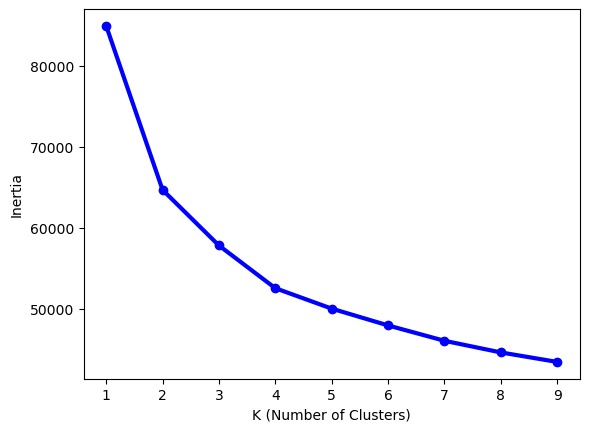

In [79]:
# d1 code
from sklearn.cluster import KMeans
# number of clusters, or k, through inertia

inertia = []
for i in range(1,10):
    kmeanModel = KMeans(n_clusters=i, n_init=10)
    kmeanModel.fit(prep_churn)
    inertia.append(kmeanModel.inertia_)
    
# elbow graph plot
plt.plot(range(1,10), inertia, 'o-', linewidth=3, color='blue')
plt.xlabel('K (Number of Clusters)')
plt.ylabel('Inertia')
plt.show()





In [80]:
# d2 code cont.

# kmean cluster creation

model = KMeans(n_clusters=2)
model.fit(prep_churn)
model.labels_

array([1, 0, 0, ..., 1, 1, 0])

In [81]:
# d2 code cont.
model.cluster_centers_

array([[2.83981154, 2.89163722, 2.92559874, 3.29642717, 3.74047899,
        2.93678838, 3.02021987, 3.07263447],
       [4.16673461, 4.14207093, 4.06991439, 3.70627803, 3.23583367,
        4.07929066, 4.01752956, 3.93477375]])

cluster # = 2, silhouette score is 0.2022991197361273
cluster # = 3, silhouette score is 0.15358953820977406
cluster # = 4, silhouette score is 0.13969378946244754
cluster # = 5, silhouette score is 0.11717812963651589
cluster # = 6, silhouette score is 0.11517361417045172
cluster # = 7, silhouette score is 0.11170352055876354
cluster # = 8, silhouette score is 0.10352313190859941
cluster # = 9, silhouette score is 0.10216778126618307


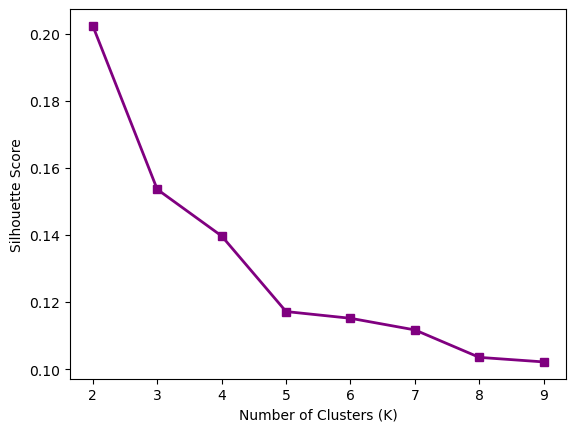

In [82]:
# d2 code cont.
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score


clusters_range = range(2, 10)

# silhouette scores list
silhouette_scores = []

# loop for clusters
for i in clusters_range:
    kmeanModel = KMeans(n_clusters=i, n_init=10)
    kmeanModel.fit(prep_churn)

# Calculate silhouette score
    silhouette_avg = silhouette_score(prep_churn, kmeanModel.labels_)
    silhouette_scores.append(silhouette_avg)
    print(f"cluster # = {i}, silhouette score is {silhouette_avg}")

# visualizing the silhouette score
plt.plot(clusters_range, silhouette_scores, 's-', linewidth=2, color='purple')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

In [83]:
# d2 code cont.
# WCSS/Inertia scoring
inertia = model.inertia_

# labels
labels = model.labels_

# Silhouette scoring
silhouette_avg = silhouette_score(prep_churn, labels)

# Davies-Bouldin Index
db_index = davies_bouldin_score(prep_churn, labels)


# print metrics
print("WCSS (Inertia):", inertia)
print("Silhouette Score:", silhouette_avg)
print("Davies Bouldin Index:", db_index)



WCSS (Inertia): 64659.527968146045
Silhouette Score: 0.20229678323339656
Davies Bouldin Index: 1.7212071598822394


## Part V:  Data Summary and Implications

### E. Summarize your data analysis by doing the following:
1. Explain the quality of the clusters created.

- WCSS(Inertia)
    
    The WCSS or Inertia measures the compactness and variance of the clusters by calculating the sum of the squared distances between every data point and its assigned cluster centroid.  The lower the score, the more compact the cluster is.  The model has a WCSS score of 64659.55, indicating the datapoints within the clusters are moderately spreadout from the cluster centroids.  This result is not ideal. 

- Silhouette Score
    
    The Silhouette Score is a metric that evaluates the quality of the clusters by meassuring how close each point in one cluster is to points in neighboring clusters.  Unlike the WCSS, a higher Silhouoette score indicates the datapoint is more compact within its own cluster and further away from neighboring clusters.  The range of the Silhouette score is 1 to -1.  The model has a Silhouette score of .202 which is only a moderate level.  This result is middle of the road as we would prefer to see it much closer to 1.

- Davies Bouldin Index
    
    The Davies Bouldin Index is a metric that evaluates how well a clustering algorithm has performed, in this case, K-Means.  It measures the average similarity between each cluster and its most similar one, calculated as the ratio of how spread out a cluster is compared to how far apart clusters are from each other(GeeksforGeeks, Davies-Bouldin index 2025).  The best possible score for Davies Bouldin Index is 0, so a low score means better clustering.  The model has a Davies Bouldin Index of 1.721, which is not horrible but also not ideal.  This result we would prefer to be closer to 0.  


2.  Discuss the results and implications of your clustering analysis.

    The elbow method was used to find the optimal K value for the model which turned out to be a k value of 2.  This provided a Silhouette score of .202.  
    The results of the arrays represent the centroid of the cluster in an 8 feature space.  An array for the 2 centroids was returned.     
    The center of the clusters from the array in the first row are [4.16642901, 4.1415767 , 4.06926054, 3.70666123, 3.23548584, 4.0790385 , 4.01690772, 3.9346099 ].  The center of the clusters from the array in the second row are [2.8393243 , 2.89137694, 2.9255549 , 3.29581615, 3.74111177, 2.93635828, 3.02023178, 3.07228442].  We are working with a 8 feature space, each row from the array has 8 values to represent the centroid of each cluster.  Analyzing the results of the clusters, cluster 1 has higher values overall verus cluster 2.  This lets us assume that cluster 2 has lower feature values in all 8 feature spaces, separating the datapoints within the cluster based on the values.      

3.  Discuss one limitation of your data analysis.
    
    One of the limitations of K-Means Clustering is that it only uses continuous variables.  That makes it difficult to get proper insight of the dataset when you are limited to a certain variable type.  Being able to use categorical variables would give more insight to the data within the dataset.    

4.  Recommend a course of action for the real-world organizational situation from part A1 based on the results and implications discussed in part E2.
    
    It is recommended that further analysis be done using different continuous variables or even the other suggested clustering method due to the mediocrity of the results.  Spending more time on the analysis will give better insight, allowing for a more informed decision than what could be made now.  After further analysis has been done, the company can then make an informed decision on the research question.


## Part VI: Demonstration

### F.  Provide a Panopto video recording that includes the presenter and a vocalized demonstration of the functionality of the code used for the analysis of the programming environment.



- https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=ddb6e067-bcc1-4e5f-9e40-b469016b99d7

### G.  List the web sources used to acquire data or segments of third-party code to support the application. Ensure the web sources are reliable.
    None used.

### H.  Acknowledge sources, using in-text citations and references, for content that is quoted, paraphrased, or summarized.
    WGU. (n.d.). Churn Data Consideration and Dictionary. Data Files and Associated Dictionary Files. https://access.wgu.edu/ASP3/aap/content/d9rkejv84kd9rk30fi2l.zip 

    Kavlakoglu, E., & Winland, V. (2025, November 17). What is K-means clustering?. IBM. https://www.ibm.com/think/topics/k-means-clustering 

    GeeksforGeeks. (2025, July 23). Demonstration of K-means assumptions. https://www.geeksforgeeks.org/machine-learning/demonstration-of-k-means-assumptions/

    GeeksforGeeks (Ed.). (2025a, July 23). Davies-Bouldin index. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/davies-bouldin-index/ 
    